In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")

In [47]:
train = pd.read_csv("data/train.csv")
store = pd.read_csv("data/store.csv")

df = train.merge(store, on="Store", how="left")

C:\Users\MY\AppData\Local\Temp\ipykernel_3988\2251189782.py:1: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  train = pd.read_csv("data/train.csv")


In [48]:
df = train.merge(store, on="Store", how="left")

In [49]:
df.shape

(1017209, 18)

In [50]:
df.head(3)

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"


In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 18 columns):
 #   Column                     Non-Null Count    Dtype  
---  ------                     --------------    -----  
 0   Store                      1017209 non-null  int64  
 1   DayOfWeek                  1017209 non-null  int64  
 2   Date                       1017209 non-null  object 
 3   Sales                      1017209 non-null  int64  
 4   Customers                  1017209 non-null  int64  
 5   Open                       1017209 non-null  int64  
 6   Promo                      1017209 non-null  int64  
 7   StateHoliday               1017209 non-null  object 
 8   SchoolHoliday              1017209 non-null  int64  
 9   StoreType                  1017209 non-null  object 
 10  Assortment                 1017209 non-null  object 
 11  CompetitionDistance        1014567 non-null  float64
 12  CompetitionOpenSinceMonth  693861 non-null   float64
 13  CompetitionO

## Data Cleaning / Preprocessing

In [52]:
df.isnull().sum()

Store                             0
DayOfWeek                         0
Date                              0
Sales                             0
Customers                         0
Open                              0
Promo                             0
StateHoliday                      0
SchoolHoliday                     0
StoreType                         0
Assortment                        0
CompetitionDistance            2642
CompetitionOpenSinceMonth    323348
CompetitionOpenSinceYear     323348
Promo2                            0
Promo2SinceWeek              508031
Promo2SinceYear              508031
PromoInterval                508031
dtype: int64

In [53]:
df.isnull().sum().sort_values(ascending=False)

Promo2SinceWeek              508031
PromoInterval                508031
Promo2SinceYear              508031
CompetitionOpenSinceYear     323348
CompetitionOpenSinceMonth    323348
CompetitionDistance            2642
DayOfWeek                         0
Store                             0
Date                              0
Sales                             0
StoreType                         0
SchoolHoliday                     0
StateHoliday                      0
Promo                             0
Open                              0
Customers                         0
Assortment                        0
Promo2                            0
dtype: int64

In [54]:
df["CompetitionDistance"] = df["CompetitionDistance"].fillna(df["CompetitionDistance"].median())

df["CompetitionOpenSinceMonth"] = df["CompetitionOpenSinceMonth"].fillna(0)

df["CompetitionOpenSinceYear"] = df["CompetitionOpenSinceYear"].fillna(0)

df["Promo2SinceWeek"] = df["Promo2SinceWeek"].fillna(0)

df["Promo2SinceYear"] = df["Promo2SinceYear"].fillna(0)

df["PromoInterval"] = df["PromoInterval"].fillna(0)

In [55]:
df.isnull().sum()

Store                        0
DayOfWeek                    0
Date                         0
Sales                        0
Customers                    0
Open                         0
Promo                        0
StateHoliday                 0
SchoolHoliday                0
StoreType                    0
Assortment                   0
CompetitionDistance          0
CompetitionOpenSinceMonth    0
CompetitionOpenSinceYear     0
Promo2                       0
Promo2SinceWeek              0
Promo2SinceYear              0
PromoInterval                0
dtype: int64

In [56]:
df["Date"] = pd.to_datetime(df["Date"])
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day
df["WeekOfYear"] = df["Date"].dt.isocalendar().week

In [57]:
df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,...,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,Year,Month,Day,WeekOfYear
0,1,5,2015-07-31,5263,555,1,1,0,1,c,...,9.0,2008.0,0,0.0,0.0,0,2015,7,31,31
1,2,5,2015-07-31,6064,625,1,1,0,1,a,...,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct",2015,7,31,31
2,3,5,2015-07-31,8314,821,1,1,0,1,a,...,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct",2015,7,31,31
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,...,9.0,2009.0,0,0.0,0.0,0,2015,7,31,31
4,5,5,2015-07-31,4822,559,1,1,0,1,a,...,4.0,2015.0,0,0.0,0.0,0,2015,7,31,31


## EDA

In [58]:
df["Open"].value_counts()

Open
1    844392
0    172817
Name: count, dtype: int64

In [59]:
df = df[df["Open"] == 1]

In [60]:
df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,...,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,Year,Month,Day,WeekOfYear
0,1,5,2015-07-31,5263,555,1,1,0,1,c,...,9.0,2008.0,0,0.0,0.0,0,2015,7,31,31
1,2,5,2015-07-31,6064,625,1,1,0,1,a,...,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct",2015,7,31,31
2,3,5,2015-07-31,8314,821,1,1,0,1,a,...,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct",2015,7,31,31
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,...,9.0,2009.0,0,0.0,0.0,0,2015,7,31,31
4,5,5,2015-07-31,4822,559,1,1,0,1,a,...,4.0,2015.0,0,0.0,0.0,0,2015,7,31,31


In [61]:
df.shape

(844392, 22)

Closed days have deterministic zero sales. Including them would bias the model and distort seasonality patterns. Therefore, operational days are filtered to model true demand.

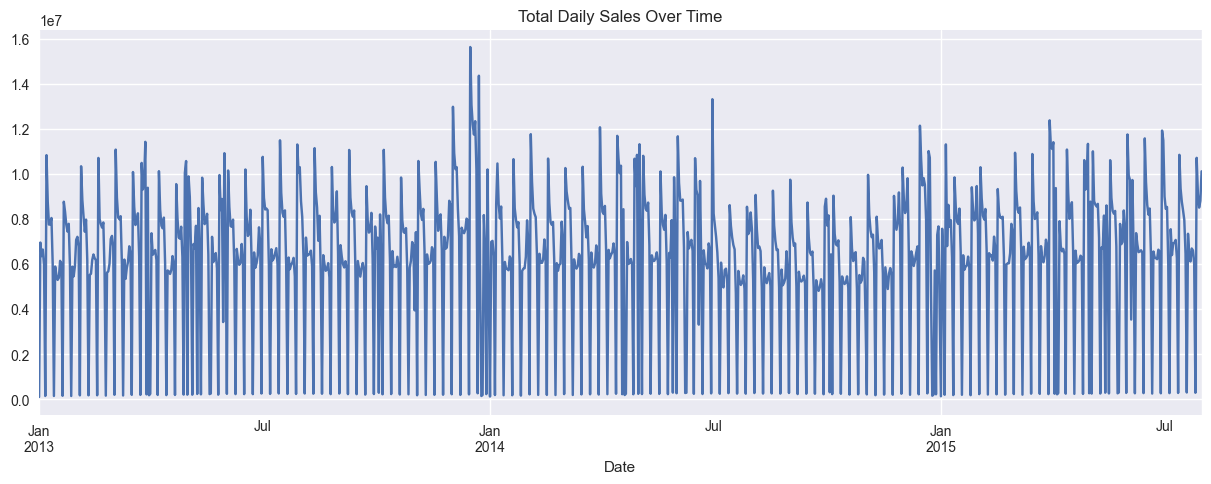

In [62]:
daily_sales = df.groupby("Date")["Sales"].sum()

plt.figure(figsize=(15,5))
daily_sales.plot()
plt.title("Total Daily Sales Over Time")
plt.show()

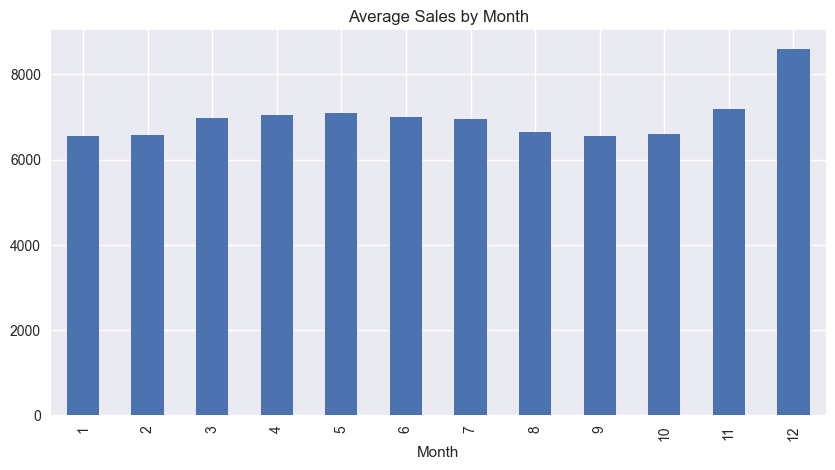

In [63]:
df.groupby("Month")["Sales"].mean().plot(kind="bar", figsize=(10,5))
plt.title("Average Sales by Month")
plt.show()

The plot shows strong yearly seasonality, with December having the highest average sales, likely due to holiday demand. Mid-year months have comparatively lower sales. This indicates that month-level seasonal features should be included in the forecasting model.

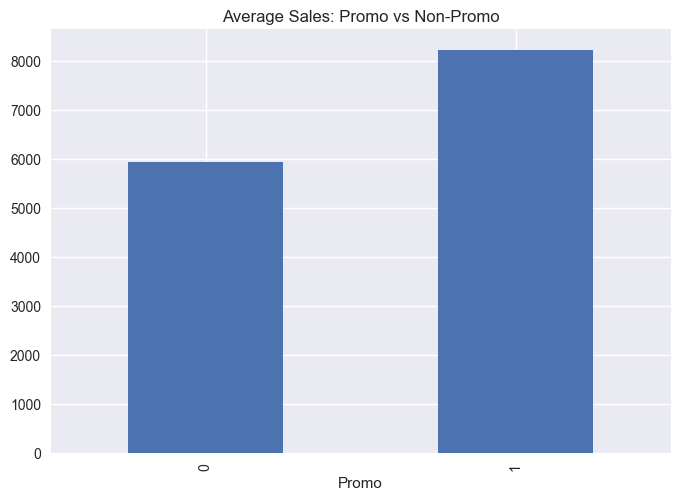

In [64]:
df.groupby("Promo")["Sales"].mean().plot(kind="bar")
plt.title("Average Sales: Promo vs Non-Promo")
plt.show()

In [65]:
df.groupby("Promo")["Sales"].mean()

Promo
0    5929.407603
1    8228.281239
Name: Sales, dtype: float64

Stores running promotions generate significantly higher average sales compared to stores without promotions. On average, sales during promotions (~8228) are substantially higher than non-promotional periods (~5929), indicating that promotional campaigns positively impact revenue.

In [66]:
monthly_sales = df.groupby(["Month", "Promo"])["Sales"].mean()

In [67]:
monthly_sales = monthly_sales.reset_index()

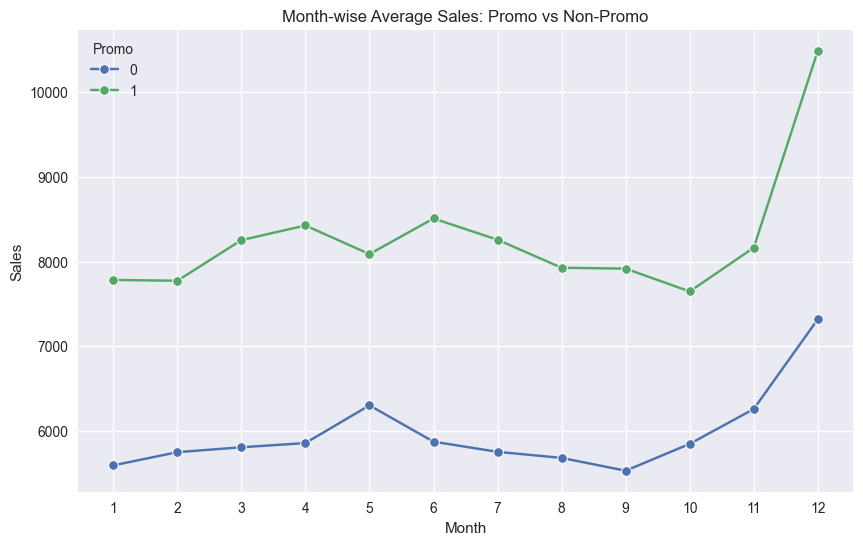

In [68]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.lineplot(data=monthly_sales, x="Month", y="Sales", hue="Promo", marker="o")

plt.title("Month-wise Average Sales: Promo vs Non-Promo")
plt.xticks(range(1,13))
plt.show()

In [69]:
df.groupby(["StoreType", "Promo"])["Sales"].mean()

StoreType  Promo
a          0         5808.500091
           1         8304.102317
b          0         9566.861686
           1        11307.994108
c          0         6028.063255
           1         8041.995526
d          0         5855.268289
           1         8017.828656
Name: Sales, dtype: float64

In [70]:
store_sales = df.groupby(["StoreType", "Promo"])["Sales"].mean().reset_index()

In [71]:
store_pivot = store_sales.pivot(index="StoreType", columns="Promo", values="Sales")
store_pivot.columns = ["Non_Promo", "Promo"]
store_pivot = store_pivot.reset_index()

store_pivot

,StoreType,Non_Promo,Promo
0,a,5808.500091,8304.102317
1,b,9566.861686,11307.994108
2,c,6028.063255,8041.995526
3,d,5855.268289,8017.828656


In [72]:
store_pivot["Lift_%"] = (
    (store_pivot["Promo"] - store_pivot["Non_Promo"])
    / store_pivot["Non_Promo"]
) * 100

store_pivot

,StoreType,Non_Promo,Promo,Lift_%
0,a,5808.500091,8304.102317,42.964658
1,b,9566.861686,11307.994108,18.199619
2,c,6028.063255,8041.995526,33.409276
3,d,5855.268289,8017.828656,36.933583


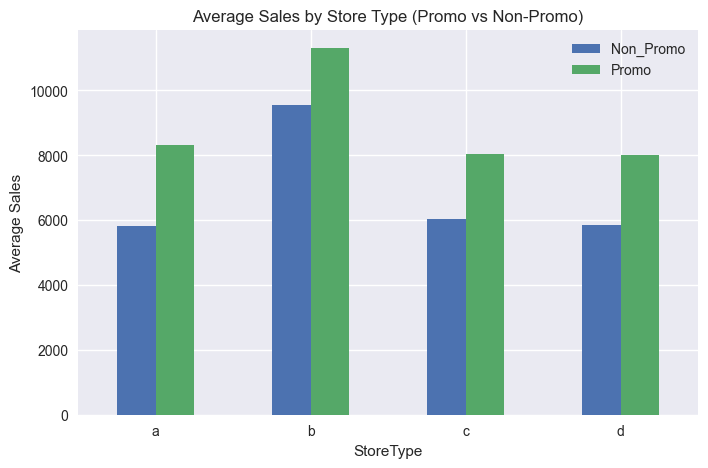

In [73]:
import matplotlib.pyplot as plt

store_pivot.set_index("StoreType")[["Non_Promo", "Promo"]].plot(kind="bar", figsize=(8,5))

plt.title("Average Sales by Store Type (Promo vs Non-Promo)")
plt.ylabel("Average Sales")
plt.xticks(rotation=0)
plt.show()

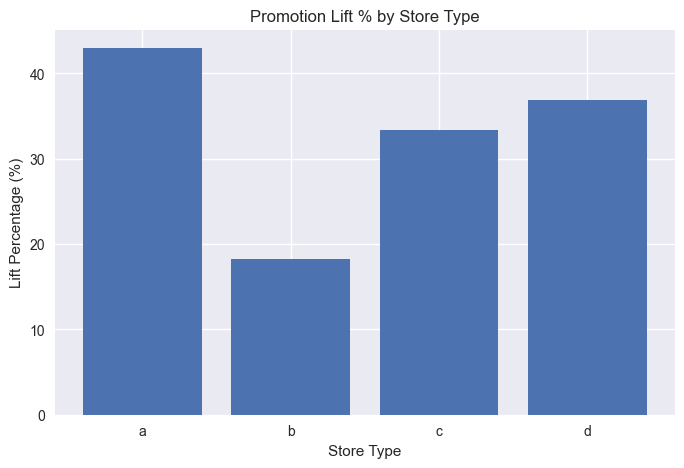

In [74]:
plt.figure(figsize=(8,5))

plt.bar(store_pivot["StoreType"], store_pivot["Lift_%"])

plt.title("Promotion Lift % by Store Type")
plt.xlabel("Store Type")
plt.ylabel("Lift Percentage (%)")
plt.show()

In [75]:
from scipy.stats import ttest_ind

promo_sales = df[df["Promo"] == 1]["Sales"]
nonpromo_sales = df[df["Promo"] == 0]["Sales"]

t_stat, p_value = ttest_ind(promo_sales, nonpromo_sales)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 363.8446754265649
P-value: 0.0


Promotional campaigns increase sales across all store types. While Store Type B generates the highest absolute sales, Store Type A exhibits the highest promotional lift (~43%), indicating stronger responsiveness to promotional activities. This suggests that promotional strategies may yield better ROI when targeted toward promotion-sensitive store segments.



<Axes: xlabel='Promo', ylabel='Sales'>

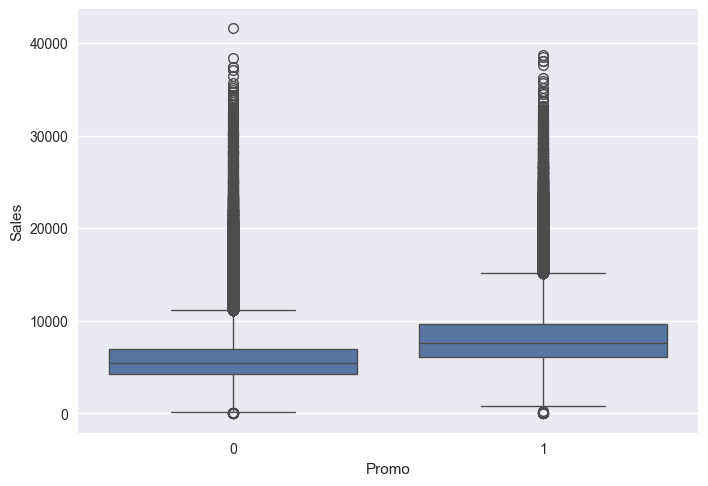

In [76]:
sns.boxplot(x="Promo", y="Sales", data=df)

The box plot shows that when Promo = 1 (promotion active), the median sales are higher compared to Promo = 0 (no promotion). This indicates that promotions have a positive impact on sales. Additionally, the sales distribution during promotions is more spread out, suggesting greater variability in sales when promotions are running. There are also several outliers in both cases, representing unusually high sales values.

In [77]:
df.corr(numeric_only=True)

,Store,DayOfWeek,Sales,Customers,Open,Promo,SchoolHoliday,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,Year,Month,Day,WeekOfYear
Store,1.000000,0.000346,0.007710,0.033977,NaN,-0.000012,0.000512,-0.027084,-0.032555,-0.008152,0.007736,0.010857,0.007768,0.000301,0.001365,-0.000119,0.001292
DayOfWeek,0.000346,1.000000,-0.178736,-0.097266,NaN,-0.289265,-0.139315,0.005533,-0.000834,-0.001303,-0.003241,-0.002736,-0.003238,0.002102,-0.019723,0.008534,-0.014402
Sales,0.007710,-0.178736,1.000000,0.823597,NaN,0.368145,0.038617,-0.035852,-0.018370,0.005266,-0.127596,-0.058476,-0.127621,0.036169,0.073600,-0.051849,0.074472
Customers,0.033977,-0.097266,0.823597,1.000000,NaN,0.182846,0.024902,-0.147798,-0.021006,0.001666,-0.202232,-0.130841,-0.202204,-0.000822,0.053856,-0.035405,0.053774
Open,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Promo,-0.000012,-0.289265,0.368145,0.182846,NaN,1.000000,0.028964,-0.002393,0.000711,0.000990,-0.000324,-0.000802,-0.000326,0.023994,-0.006408,-0.126452,0.006950
SchoolHoliday,0.000512,-0.139315,0.038617,0.024902,NaN,0.028964,1.000000,-0.004258,-0.000131,0.000126,-0.008245,-0.008062,-0.008248,-0.038679,0.118485,0.038081,0.079604
CompetitionDistance,-0.027084,0.005533,-0.035852,-0.147798,NaN,-0.002393,-0.004258,1.000000,-0.032083,-0.001218,-0.141317,-0.123999,-0.141380,0.000633,0.003888,-0.000227,0.003697
CompetitionOpenSinceMonth,-0.032555,-0.000834,-0.018370,-0.021006,NaN,0.000711,-0.000131,-0.032083,1.000000,0.785326,-0.082561,-0.109522,-0.082488,-0.000532,-0.001328,-0.000210,-0.001300
CompetitionOpenSinceYear,-0.008152,-0.001303,0.005266,0.001666,NaN,0.000990,0.000126,-0.001218,0.785326,1.000000,-0.098571,-0.125080,-0.098503,-0.000156,-0.000758,-0.000336,-0.000742


Sales show a strong positive correlation with the number of customers (0.82) and a moderate positive relationship with promotions (0.37). Most other variables such as competition distance, holidays, and calendar features show very weak correlations with sales, indicating limited influence.

## Feature Engineering

In [78]:
df = pd.get_dummies(
    df,
    columns=["StateHoliday", "StoreType", "Assortment", "PromoInterval"],
    drop_first=True
)

In [79]:
df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,SchoolHoliday,CompetitionDistance,CompetitionOpenSinceMonth,...,StateHoliday_b,StateHoliday_c,StoreType_b,StoreType_c,StoreType_d,Assortment_b,Assortment_c,"PromoInterval_Feb,May,Aug,Nov","PromoInterval_Jan,Apr,Jul,Oct","PromoInterval_Mar,Jun,Sept,Dec"
0,1,5,2015-07-31,5263,555,1,1,1,1270.0,9.0,...,False,False,False,True,False,False,False,False,False,False
1,2,5,2015-07-31,6064,625,1,1,1,570.0,11.0,...,False,False,False,False,False,False,False,False,True,False
2,3,5,2015-07-31,8314,821,1,1,1,14130.0,12.0,...,False,False,False,False,False,False,False,False,True,False
3,4,5,2015-07-31,13995,1498,1,1,1,620.0,9.0,...,False,False,False,True,False,False,True,False,False,False
4,5,5,2015-07-31,4822,559,1,1,1,29910.0,4.0,...,False,False,False,False,False,False,False,False,False,False


In [80]:
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day
df["WeekOfYear"] = df["Date"].dt.isocalendar().week
df["IsWeekend"] = df["DayOfWeek"].isin([6,7]).astype(int)

In [81]:
df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,SchoolHoliday,CompetitionDistance,CompetitionOpenSinceMonth,...,StateHoliday_c,StoreType_b,StoreType_c,StoreType_d,Assortment_b,Assortment_c,"PromoInterval_Feb,May,Aug,Nov","PromoInterval_Jan,Apr,Jul,Oct","PromoInterval_Mar,Jun,Sept,Dec",IsWeekend
0,1,5,2015-07-31,5263,555,1,1,1,1270.0,9.0,...,False,False,True,False,False,False,False,False,False,0
1,2,5,2015-07-31,6064,625,1,1,1,570.0,11.0,...,False,False,False,False,False,False,False,True,False,0
2,3,5,2015-07-31,8314,821,1,1,1,14130.0,12.0,...,False,False,False,False,False,False,False,True,False,0
3,4,5,2015-07-31,13995,1498,1,1,1,620.0,9.0,...,False,False,True,False,False,True,False,False,False,0
4,5,5,2015-07-31,4822,559,1,1,1,29910.0,4.0,...,False,False,False,False,False,False,False,False,False,0


In [82]:
# Lag Features
df = df.sort_values(["Store","Date"])

df["Lag_1"] = df.groupby("Store")["Sales"].shift(1)
df["Lag_7"] = df.groupby("Store")["Sales"].shift(7)
df["Lag_30"] = df.groupby("Store")["Sales"].shift(30)

In [83]:
df["RollingMean_7"] = df.groupby("Store")["Sales"].shift(1).rolling(7).mean()
df["RollingMean_30"] = df.groupby("Store")["Sales"].shift(1).rolling(30).mean()

In [84]:
df = df.dropna()

In [85]:
df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,SchoolHoliday,CompetitionDistance,CompetitionOpenSinceMonth,...,Assortment_c,"PromoInterval_Feb,May,Aug,Nov","PromoInterval_Jan,Apr,Jul,Oct","PromoInterval_Mar,Jun,Sept,Dec",IsWeekend,Lag_1,Lag_7,Lag_30,RollingMean_7,RollingMean_30
975955,1,3,2013-02-06,6140,693,1,1,0,1270.0,9.0,...,False,False,False,False,0,6049.0,3725.0,5530.0,5388.428571,5103.833333
974840,1,4,2013-02-07,5499,675,1,1,0,1270.0,9.0,...,False,False,False,False,0,6140.0,4601.0,4327.0,5733.428571,5124.166667
973725,1,5,2013-02-08,5681,630,1,1,0,1270.0,9.0,...,False,False,False,False,0,5499.0,4709.0,4486.0,5861.714286,5163.233333
972610,1,6,2013-02-09,5370,656,1,0,0,1270.0,9.0,...,False,False,False,False,1,5681.0,5633.0,4997.0,6000.571429,5203.066667
970380,1,1,2013-02-11,4409,599,1,0,0,1270.0,9.0,...,False,False,False,False,0,5370.0,5970.0,7176.0,5963.000000,5215.500000


In [86]:
df = df.drop("Customers", axis=1)

In [87]:
df = df.astype({col: "int" for col in df.select_dtypes("bool").columns})

In [88]:
df = df.sort_values(["Store", "Date"])

In [89]:
train = df[df["Date"] < "2015-01-01"]
test = df[df["Date"] >= "2015-01-01"]

In [90]:
X_train = train.drop(["Sales", "Date"], axis=1)
y_train = train["Sales"]

X_test = test.drop(["Sales", "Date"], axis=1)
y_test = test["Sales"]

In [91]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [92]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

# Train model
lr.fit(X_train, y_train)

# Predictions
y_pred_lr = lr.predict(X_test)

# Evaluation
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Results")
print("MAE:", mae_lr)
print("RMSE:", rmse_lr)
print("R2:", r2_lr)

Linear Regression Results
MAE: 1024.607193286993
RMSE: 1417.8592737521326
R2: 0.7816418741672949


In [93]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

# Train model
rf.fit(X_train, y_train)

# Predictions
y_pred_rf = rf.predict(X_test)

# Evaluation
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("\nRandom Forest Results")
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R2:", r2_rf)


Random Forest Results
MAE: 727.951406395172
RMSE: 1050.0393804149035
R2: 0.8802393137423854


In [94]:
!pip install xgboost

In [95]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

# Train model
xgb.fit(X_train, y_train)

# Predictions
y_pred_xgb = xgb.predict(X_test)

# Evaluation
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

print("\nXGBoost Results")
print("MAE:", mae_xgb)
print("RMSE:", rmse_xgb)
print("R2:", r2_xgb)


XGBoost Results
MAE: 667.7810668945312
RMSE: 943.7244698533572
R2: 0.9032627940177917


Linear Regression provides a baseline performance.
Random Forest captures non-linear relationships and feature interactions.
XGBoost typically performs better in structured data problems because it handles complex patterns and feature importance effectively.

In [96]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "XGBoost"],
    "MAE": [mae_lr, mae_rf, mae_xgb],
    "RMSE": [rmse_lr, rmse_rf, rmse_xgb],
    "R2": [r2_lr, r2_rf, r2_xgb]
})

print("\nModel Comparison")
print(results)


Model Comparison
               Model          MAE         RMSE        R2
0  Linear Regression  1024.607193  1417.859274  0.781642
1      Random Forest   727.951406  1050.039380  0.880239
2            XGBoost   667.781067   943.724470  0.903263


Tree-based models such as Random Forest and XGBoost outperform Linear Regression, indicating the presence of non-linear relationships in sales data.
The best performing model will be used for future sales forecasting.

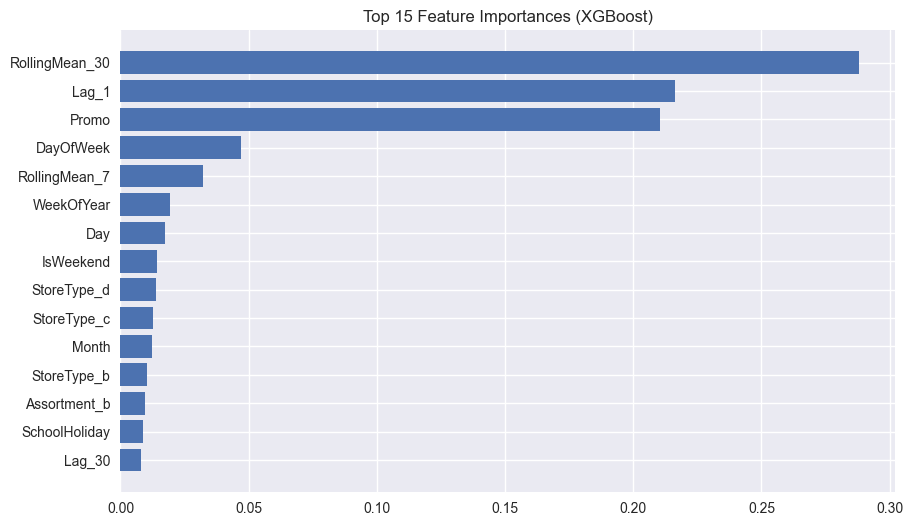

In [97]:
import matplotlib.pyplot as plt

importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgb.feature_importances_
})

importance = importance.sort_values("Importance", ascending=False)

# Plot
plt.figure(figsize=(10,6))
plt.barh(importance["Feature"][:15], importance["Importance"][:15])
plt.gca().invert_yaxis()
plt.title("Top 15 Feature Importances (XGBoost)")
plt.show()

Lag features such as Lag_1 and Lag_7 are among the most important predictors, showing that past sales strongly influence future demand.
Promotional variables also rank highly, confirming that marketing campaigns significantly impact store revenue.

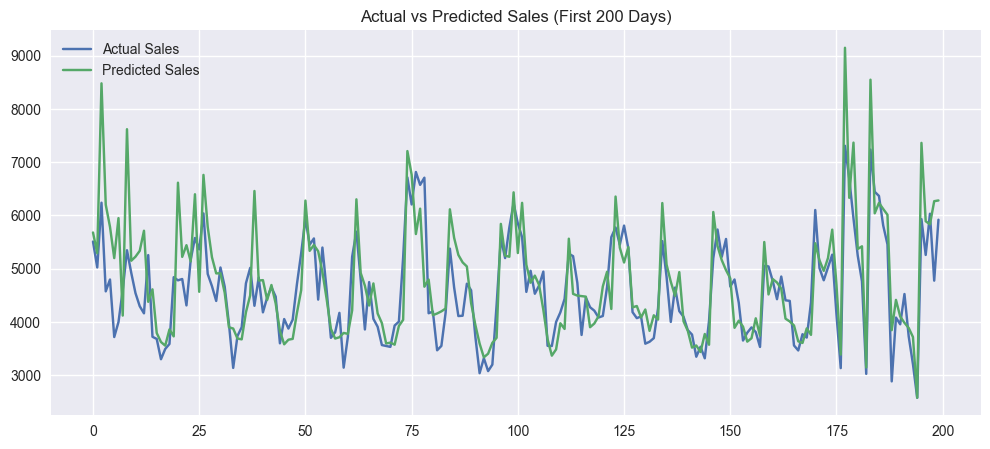

In [98]:
plt.figure(figsize=(12,5))

plt.plot(y_test.values[:200], label="Actual Sales")
plt.plot(y_pred_xgb[:200], label="Predicted Sales")

plt.legend()
plt.title("Actual vs Predicted Sales (First 200 Days)")
plt.show()

In [99]:
last_data = df.sort_values("Date").groupby("Store").tail(1)

last_data.head()

,Store,DayOfWeek,Date,Sales,Open,Promo,SchoolHoliday,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,...,Assortment_c,"PromoInterval_Feb,May,Aug,Nov","PromoInterval_Jan,Apr,Jul,Oct","PromoInterval_Mar,Jun,Sept,Dec",IsWeekend,Lag_1,Lag_7,Lag_30,RollingMean_7,RollingMean_30
23706,292,5,2015-07-10,1012,1,0,0,1100.0,6.0,2009.0,...,0,0,0,0,0,4777.0,8237.0,7304.0,4133.285714,7013.766667
18715,876,3,2015-07-15,4739,1,1,1,21790.0,4.0,2005.0,...,0,1,0,0,0,11806.0,23927.0,7655.0,13243.714286,11076.033333
580,581,5,2015-07-31,6455,1,1,1,7250.0,12.0,2013.0,...,0,0,0,0,0,5747.0,4564.0,3985.0,5597.428571,5194.500000
615,616,5,2015-07-31,11786,1,1,1,3040.0,8.0,2011.0,...,1,0,0,1,0,8137.0,6564.0,7782.0,7379.142857,8106.166667
613,614,5,2015-07-31,7698,1,1,1,1160.0,12.0,2012.0,...,0,0,0,0,0,7054.0,5790.0,6228.0,6665.857143,6798.733333


In [100]:
forecast_days = 30

In [101]:
future_dates = pd.date_range(
    start=df["Date"].max() + pd.Timedelta(days=1),
    periods=forecast_days
)

In [102]:
stores = df["Store"].unique()

future_df = pd.MultiIndex.from_product(
    [stores, future_dates],
    names=["Store","Date"]
).to_frame(index=False)

future_df.head()

,Store,Date
0,1,2015-08-01
1,1,2015-08-02
2,1,2015-08-03
3,1,2015-08-04
4,1,2015-08-05


In [107]:
future_df["DayOfWeek"] = future_df["Date"].dt.dayofweek + 1
future_df["Year"] = future_df["Date"].dt.year
future_df["Month"] = future_df["Date"].dt.month
future_df["Day"] = future_df["Date"].dt.day
future_df["WeekOfYear"] = future_df["Date"].dt.isocalendar().week.astype(int)

future_df["IsWeekend"] = future_df["DayOfWeek"].isin([6,7]).astype(int)

In [108]:
future_df.head()

,Store,Date,DayOfWeek_x,Month_x,Year_x,Day_x,WeekOfYear_x,IsWeekend_x,DayOfWeek_y,Open,...,Lag_7,Lag_30,RollingMean_7,RollingMean_30,DayOfWeek,Year,Month,Day,WeekOfYear,IsWeekend
0,1,2015-08-01,6,8,2015,1,31,1,3,1,...,5263,5263,5263,5263,6,2015,8,1,31,1
1,1,2015-08-02,7,8,2015,2,31,1,3,1,...,5263,5263,5263,5263,7,2015,8,2,31,1
2,1,2015-08-03,1,8,2015,3,32,0,3,1,...,5263,5263,5263,5263,1,2015,8,3,32,0
3,1,2015-08-04,2,8,2015,4,32,0,3,1,...,5263,5263,5263,5263,2,2015,8,4,32,0
4,1,2015-08-05,3,8,2015,5,32,0,3,1,...,5263,5263,5263,5263,3,2015,8,5,32,0


In [109]:
set(X_train.columns) - set(future_df.columns)

set()

In [110]:
X_future = future_df[X_train.columns]

future_df["Predicted_Sales"] = xgb.predict(X_future)

In [111]:
future_df[["Store","Date","Predicted_Sales"]].head()

,Store,Date,Predicted_Sales
0,1,2015-08-01,5782.801758
1,1,2015-08-02,5629.224609
2,1,2015-08-03,7024.038086
3,1,2015-08-04,5238.567871
4,1,2015-08-05,5382.021484


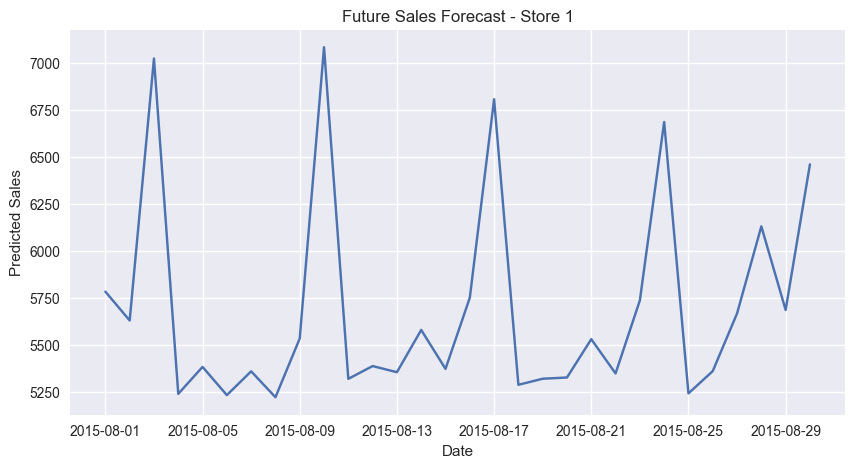

In [112]:
store1 = future_df[future_df["Store"] == 1]

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(store1["Date"], store1["Predicted_Sales"])
plt.title("Future Sales Forecast - Store 1")
plt.xlabel("Date")
plt.ylabel("Predicted Sales")
plt.show()

In [113]:
future_df.to_csv("future_sales_forecast.csv", index=False)

This project aimed to forecast retail store sales using historical sales data and store-related features. After performing data cleaning, exploratory data analysis, and feature engineering (including time-based, lag, and rolling features), multiple machine learning models were trained and evaluated. Tree-based models such as Random Forest and XGBoost captured the sales patterns more effectively than linear models. The final model was used to predict future sales, which can help retailers with better inventory management, promotion planning, and operational decision-making.